In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('../data/Loan_Default.csv')
sns.set_theme(style='whitegrid')


In [7]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


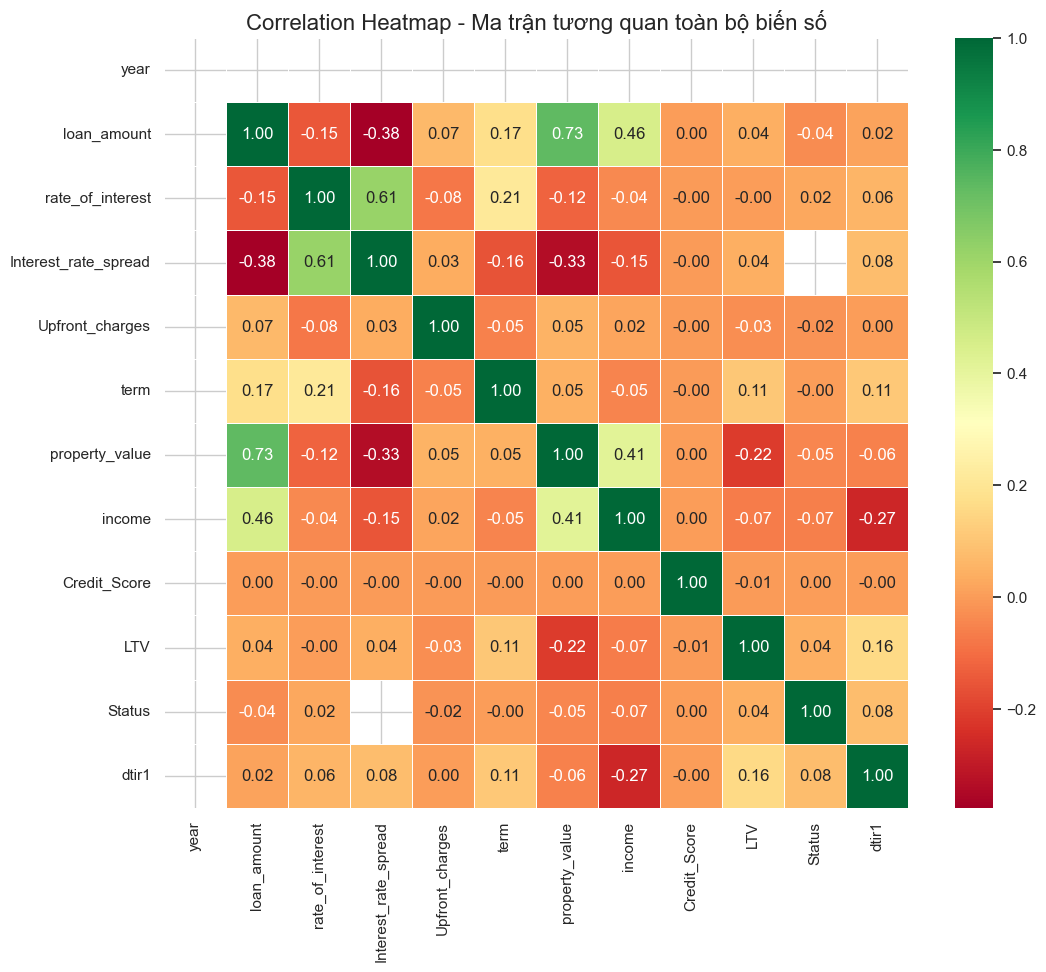

In [11]:


# nhận diện số 
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# ma trận tương quan
cols_to_corr = [col for col in numerical_df.columns if col.lower() != 'id']
corr_matrix = numerical_df[cols_to_corr].corr()

#  Vẽ Correlation Heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap - Ma trận tương quan toàn bộ biến số', fontsize=16)
plt.show()

Các cặp biến có độ tương quan mạnh :
property_value | loan_amount             : 0.73
interest_rate_spread | rate_of_interest  : 0.61
interest_rate_spread | loan_amount       : -0.38
property_value | interest_rate_spread    : -0,33
 



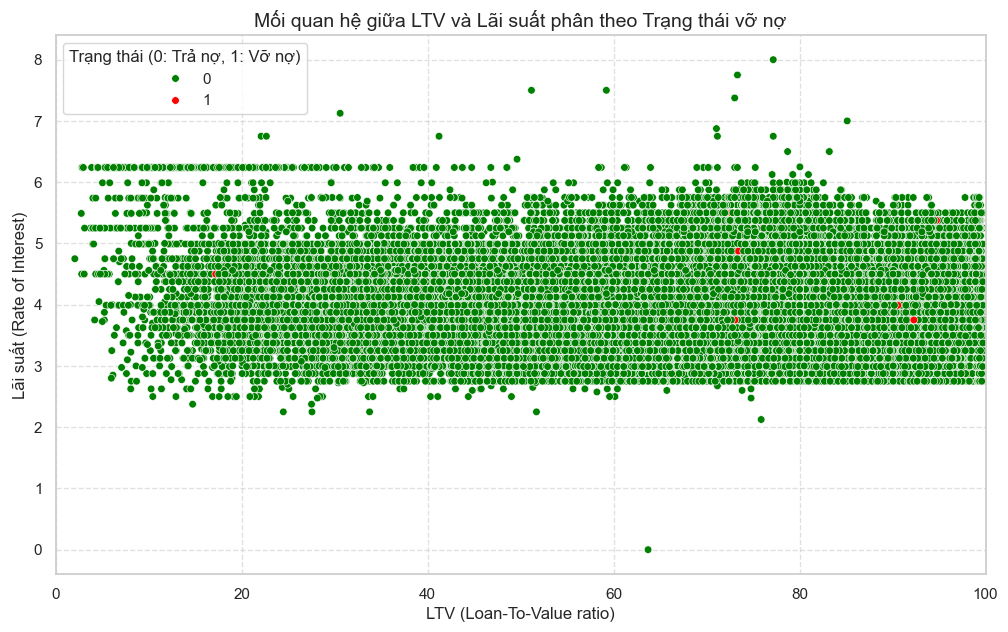

In [ ]:
df_plot = df.sort_values(by='Status', ascending=True)


plt.figure(figsize=(12, 7))

custom_palette = {0: "green", 1: "red"}
sns.scatterplot(data=df_plot, x='LTV', y='rate_of_interest', hue='Status', 
                palette=custom_palette, alpha=1, s=30)
plt.xlim(0, 100)

plt.title('Mối quan hệ giữa LTV và Lãi suất phân theo Trạng thái vỡ nợ', fontsize=14)
plt.xlabel('LTV (Loan-To-Value ratio)', fontsize=12)
plt.ylabel('Lãi suất (Rate of Interest)', fontsize=12)


plt.legend(title='Trạng thái (0: Trả nợ, 1: Vỡ nợ)')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Những người có LTV cao (vay nhiều nhưng vốn tự có ít) sẽ bị ngân hàng áp mức lãi suất cao hơn . Vì các ngân hàng làm thế để gây áp lực lên con nợ để thu hồi vốn gấp



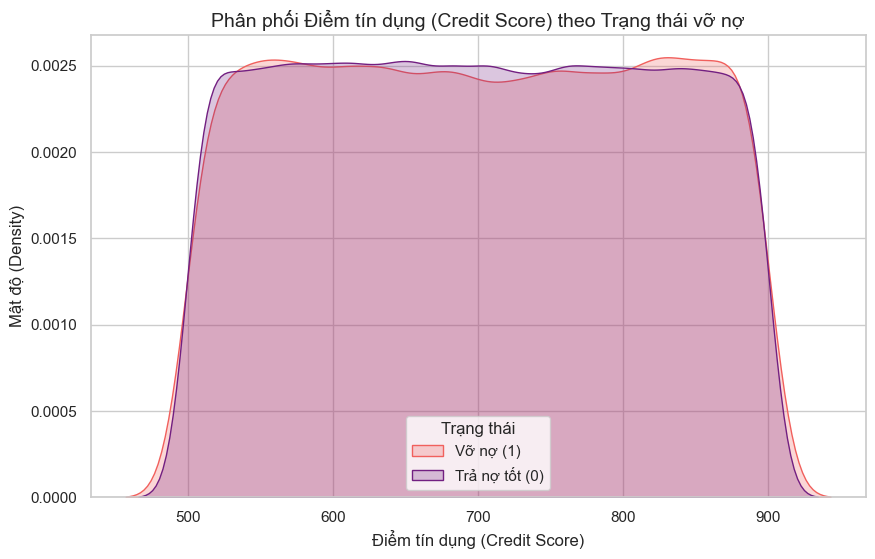

In [10]:



plt.figure(figsize=(10, 6))


sns.kdeplot(data=df, x='Credit_Score', hue='Status', fill=True, palette='magma', common_norm=False)


plt.title('Phân phối Điểm tín dụng (Credit Score) theo Trạng thái vỡ nợ', fontsize=14)
plt.xlabel('Điểm tín dụng (Credit Score)', fontsize=12)
plt.ylabel('Mật độ (Density)', fontsize=12)


plt.legend(title='Trạng thái', labels=['Vỡ nợ (1)', 'Trả nợ tốt (0)'])

plt.show()